# 01 Region Setup

This notebook prepares the Marshfield coastal flood region. It reads the configured SFINCS bbox from the Location override, builds/reads the study AOI, collects required coastal static inputs, fetches coastal land/wave geometry, writes SSURGO infiltration rasters, and plots the collected products.

**Stages:**

### 1. Parameters and Configuration

Load Region config and show the configured bbox/static record syntax.

### 2. Configured Coastal Region

Build/read the study AOI, read the configured SFINCS bbox, fetch coastal land geometry, derive wave-coupling geometry when enabled, and plot the region context.

### 3. Required Static Data

Collect terrain, landcover, coastline, wave geometry, and SSURGO infiltration inputs for SFINCS. Marshfield has no Wflow static collection in this notebook.

### 4. Collected Input Plot

Plot the collected coastal static inputs and infiltration summaries.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

notebook_root = Path.cwd().resolve()
location_root = notebook_root.parent
repo_root = location_root.parents[1]
src_root = repo_root / "src"
src_path = str(src_root)
if src_path in sys.path:
    sys.path.remove(src_path)
sys.path.insert(0, src_path)
importlib.invalidate_caches()
for module_name in [name for name in sys.modules if name == "sfincs_runs" or name.startswith("sfincs_runs.")]:
    del sys.modules[module_name]

import sfincs_runs.build_base.region_notebook as region

pd.set_option("display.max_colwidth", 140)


## 1. Parameters & Configuration


In [2]:
runtime = region.load_coastal_region_setup_runtime(
    location_root,
    static_input_settings={"fetch_dem": True},
)

pd.Series(
    {
        "location": runtime.config["project"]["place_name"],
        "configured_bbox": runtime.config["static_sources"]["bbox"]["output"],
        "bbox_record_syntax": 'location_root / "data" / "static" / "aoi" / "bbox.geojson"',
        "static_record_syntax": 'location_root / "data" / "static" / "..."',
        "wflow_static_collection": "not applicable for coastal Marshfield",
    },
    name="region_setup_parameters",
)


location                                                          Marshfield, MA, USA
configured_bbox                                          data/static/aoi/bbox.geojson
bbox_record_syntax         location_root / "data" / "static" / "aoi" / "bbox.geojson"
static_record_syntax                        location_root / "data" / "static" / "..."
wflow_static_collection                         not applicable for coastal Marshfield
Name: region_setup_parameters, dtype: str

## 2. Configured Coastal Region


study_area       locations/marshfield/data/static/aoi/study_area.geojson
bbox                   locations/marshfield/data/static/aoi/bbox.geojson
bbox_wgs84                 (-70.776672, 42.05745, -70.587158, 42.165439)
source_points                                                      68675
bbox_source                        configured static_sources.bbox.output
Name: configured_coastal_region, dtype: object

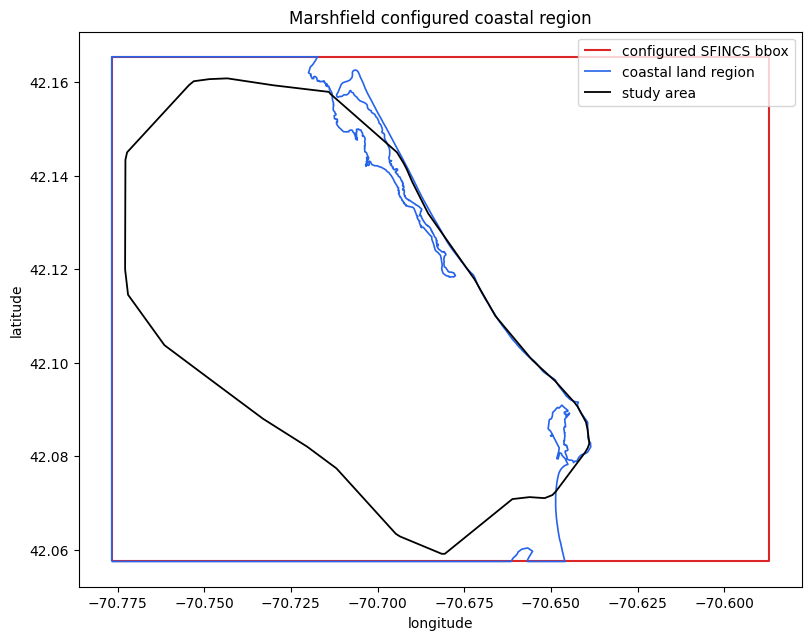

In [3]:
domain = region.build_configured_coastal_region_domain(runtime)

display(domain.summary)
region.plot_configured_coastal_region(runtime, domain)
plt.show()


## 3. Required Coastal Static Data


In [4]:
static_data = region.collect_required_coastal_static_data(runtime, domain)

if static_data.dem_refresh is not None:
    display(static_data.dem_refresh)
display(static_data.terrain_landcover.summary)
display(static_data.coastal_region)
if static_data.wave_geometry is not None:
    display(static_data.wave_geometry)
display(static_data.ssurgo)
static_data.summary


dem_path        locations/marshfield/data/static/raw/topo/cudem_10_marshfield.tif
status                                    kept (existing tif already covers bbox)
tiles_merged                                                                    0
bytes                                                                    21604308
Name: inland_dem, dtype: object

dem                      locations/marshfield/data/static/processed/cudem_region_setup.tif
landcover_raw           locations/marshfield/data/static/raw/landcover/worldcover_bbox.tif
landcover_source                                                                     local
landcover           locations/marshfield/data/static/processed/worldcover_region_setup.tif
Name: clipped_rasters, dtype: str

raw_coastline_segments                                                                   24
land_polygons                                                                             1
ocean_polygons                                                                            1
other_polygons                                                                            1
raw_coastline              locations/marshfield/data/static/processed/osm_coastline.geojson
coastal_region            locations/marshfield/data/static/processed/coastal_region.geojson
Name: coastline, dtype: object

offshore_region            locations/marshfield/data/static/processed/offshore_region.geojson
seaward_edge                  locations/marshfield/data/static/processed/seaward_edge.geojson
waterlevel_boundary    locations/marshfield/data/static/processed/waterlevel_boundary.geojson
boundary_buffer_m                                                                       180.0
offshore_area_km2                                                                       83.64
seaward_edge_km                                                                         11.99
Name: wave_geometry, dtype: object

soil_polygons                                                                               2155
soil_mukeys                                                                                  185
ssurgo_attribute_rows                                                                        891
bounds_before_axis_check                          (-70.960113, 41.810624, -70.451001, 42.395073)
bounds_after_axis_check                           (-70.960113, 41.810624, -70.451001, 42.395073)
ssurgo                            locations/marshfield/data/static/soils/ssurgo_mapunitpoly.gpkg
ssurgo_attributes           locations/marshfield/data/static/soils/ssurgo_mapunit_attributes.csv
hsg_raster                                 locations/marshfield/data/static/soils/hsg_mfield.tif
ksat_raster                          locations/marshfield/data/static/soils/ksat_mmhr_mfield.tif
rasterized_soil_polygons                                                                    1685
soil_pixels                   

terrain_landcover                                                                ready
dem_refresh                                    kept (existing tif already covers bbox)
coastal_region       locations/marshfield/data/static/processed/coastal_region.geojson
wave_geometry                                                                    ready
ssurgo                           locations/marshfield/data/static/soils/hsg_mfield.tif
Name: coastal_static_collection, dtype: str

## 4. Collected Input Plot


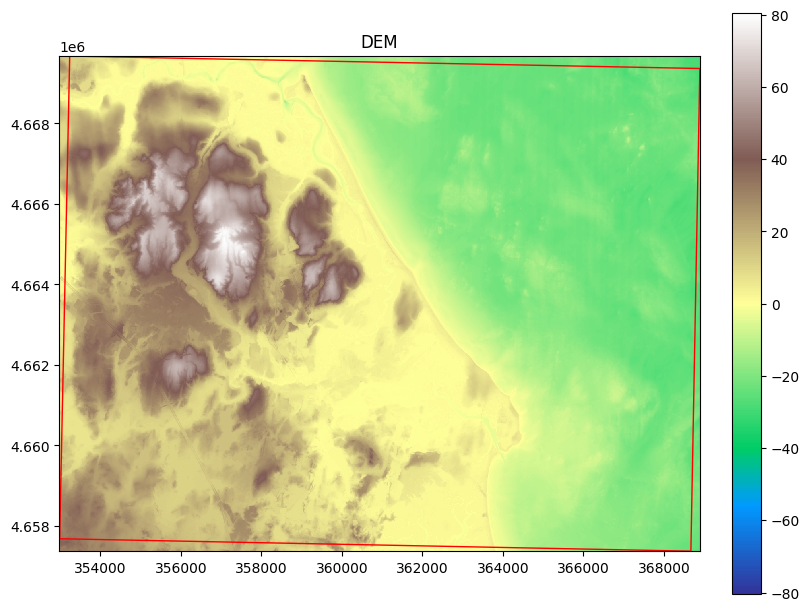

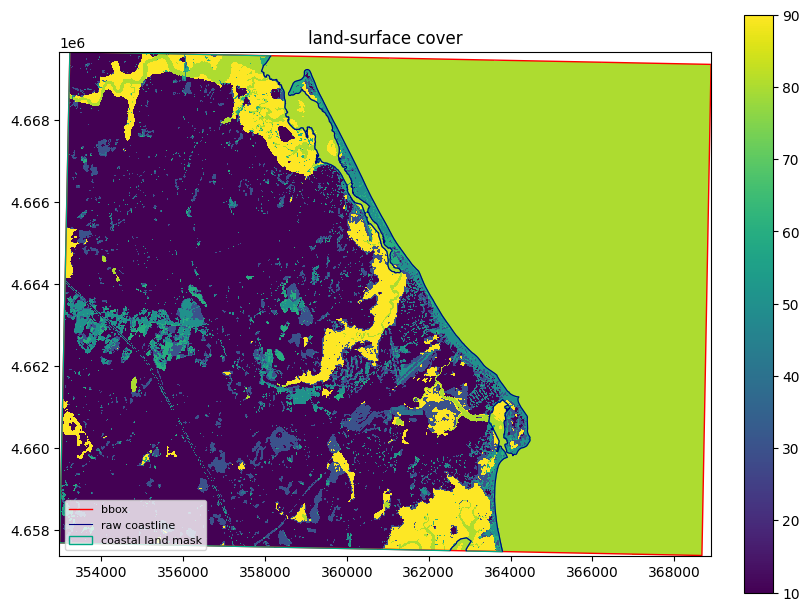

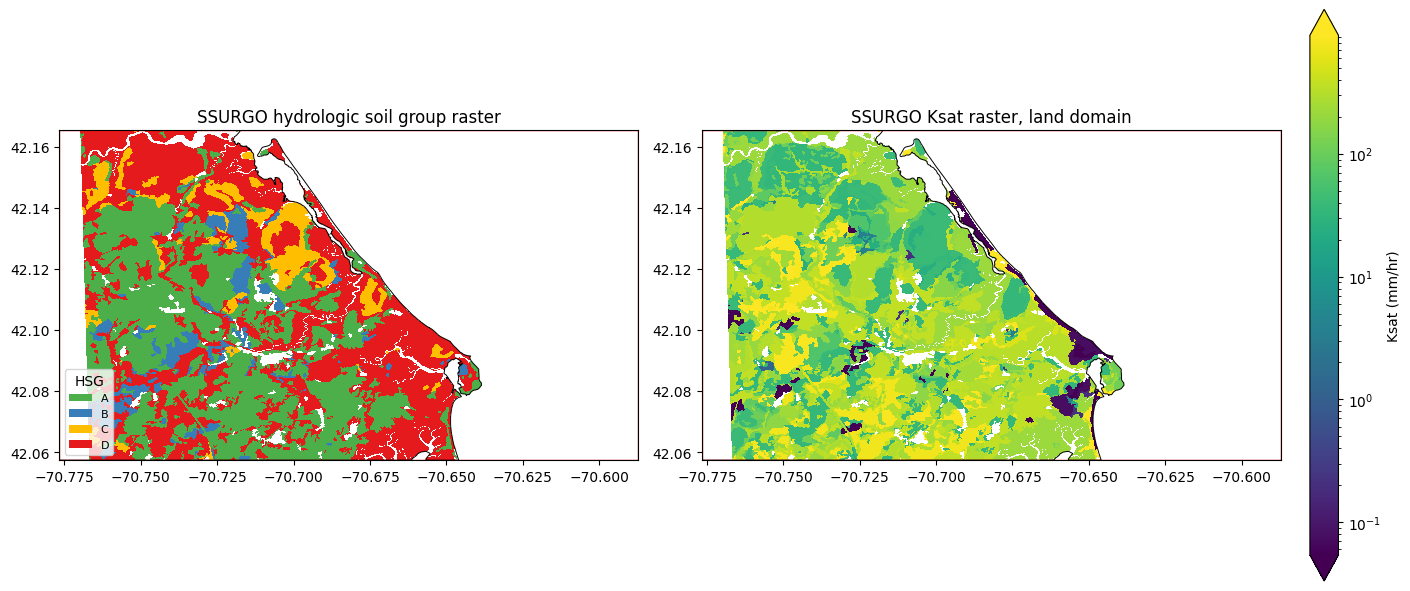

,hsg_code,hsg,pixel_count
0,1,A,373164
1,2,B,59993
2,3,C,69366
3,4,D,411035


hsg_pixels       913558.000000
ksat_pixels      913558.000000
ksat_min_mmhr         0.046763
ksat_p50_mmhr       213.349686
ksat_p98_mmhr       924.770630
Name: ssurgo_infiltration_rasters, dtype: float64

In [5]:
coastal_static_qa = region.plot_collected_coastal_static_data(runtime, static_data, domain)

display(coastal_static_qa.hsg_summary)
coastal_static_qa.infiltration_summary
